In [20]:
import sys
sys.path.insert(0, "../Tools")

import pandas
import numpy as np
import tensorflow as tf
from pathlib import Path
from dna_affinity_data import DNAAffinityDataProcessor

In [21]:
# Initialize and process the data
processor = DNAAffinityDataProcessor(
    sequences_path="../../Data/training_seqs_small.txt",
    dbps_path="../../Data/training_DBPs_small.txt",
    affinity_path="../../Data/training_data_small.txt",
)
df_affinity = processor.process()

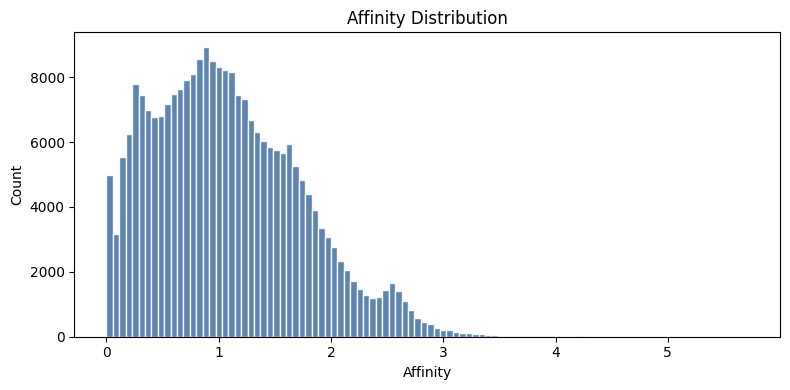

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df_affinity["Affinity"], bins=100, color="#4C78A8", edgecolor="white", alpha=0.9)
plt.title("Affinity Distribution")
plt.xlabel("Affinity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [23]:
# Load pre-computed protein embeddings (ProtBERT, 1024-dim)
embeddings_df = pandas.read_csv("../../Data/training_DBPs_embedded_small.txt", sep=",")
embedding_cols = [col for col in embeddings_df.columns if col.startswith("dim_")]
# Create protein name -> embedding mapping from the txt file
protein_embeddings_dict = {}
if 'sequence' in embeddings_df.columns:
    # If sequence column exists, use it as the protein identifier
    for idx, row in embeddings_df.iterrows():
        protein_id = row['sequence']
        embedding = row[embedding_cols].values.astype(np.float32)
        protein_embeddings_dict[protein_id] = embedding

# Build model inputs
dna_onehot = np.stack(df_affinity["DNA_onehot"].to_list(), axis=0).astype(np.float32)
labels = df_affinity["Affinity"].to_numpy(dtype=np.float32)

# Load protein embeddings for each row
protein_embeddings_list = []
for protein_name in df_affinity["Protein"]:
    if protein_name in protein_embeddings_dict:
        protein_embeddings_list.append(protein_embeddings_dict[protein_name])
    else:
        # Fallback: use zero vector if protein not found
        print(f"Warning: Protein '{protein_name}' not found in embeddings, using zero vector")
        protein_embeddings_list.append(np.zeros(1024, dtype=np.float32))

protein_embeddings = np.stack(protein_embeddings_list, axis=0).astype(np.float32)

# Train/validation split
rng = np.random.default_rng(42)
indices = rng.permutation(len(labels))
split = int(0.8 * len(labels))
train_idx, val_idx = indices[:split], indices[split:]

dna_train, dna_val = dna_onehot[train_idx], dna_onehot[val_idx]
prot_train, prot_val = protein_embeddings[train_idx], protein_embeddings[val_idx]
y_train, y_val = labels[train_idx], labels[val_idx]

embedding_dim = protein_embeddings.shape[1]  # Should be 1024

In [24]:
dna_input = tf.keras.Input(shape=(36, 4), name="dna_onehot")
prot_input = tf.keras.Input(shape=(embedding_dim,), name="protein_embedding")

x_dna = tf.keras.layers.Conv1D(32, 5, padding="same", activation="relu")(dna_input)
x_dna = tf.keras.layers.BatchNormalization()(x_dna)
x_dna = tf.keras.layers.MaxPooling1D(2)(x_dna)
x_dna = tf.keras.layers.Conv1D(64, 3, padding="same", activation="relu")(x_dna)
x_dna = tf.keras.layers.GlobalMaxPooling1D()(x_dna)

# Use pre-computed protein embeddings directly (no need for Embedding layer)
x_prot = tf.keras.layers.Dense(64, activation="relu")(prot_input)

x = tf.keras.layers.Concatenate()([x_dna, x_prot])
x = tf.keras.layers.Dense(64, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
output = tf.keras.layers.Dense(1, name="affinity")(x)

In [25]:
def within_tolerance(y_true, y_pred, tol=0.5):
    return tf.reduce_mean(tf.cast(tf.abs(y_true - y_pred) <= tol, tf.float32))

model = tf.keras.Model(inputs=[dna_input, prot_input], outputs=output)
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse"), within_tolerance],
)
train_ds = tf.data.Dataset.from_tensor_slices(
    ({"dna_onehot": dna_train, "protein_embedding": prot_train}, y_train)
).shuffle(2048, seed=42).batch(128).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices(
    ({"dna_onehot": dna_val, "protein_embedding": prot_val}, y_val)
).batch(128).prefetch(tf.data.AUTOTUNE)
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    )
 ]

In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=1,
 )

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2454 - mae: 0.3496 - rmse: 0.4954 - within_tolerance: 0.4519 - val_loss: 0.1586 - val_mae: 0.2615 - val_rmse: 0.3982 - val_within_tolerance: 0.4630
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1580 - mae: 0.2774 - rmse: 0.3974 - within_tolerance: 0.4484 - val_loss: 0.1325 - val_mae: 0.2512 - val_rmse: 0.3640 - val_within_tolerance: 0.4492
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1430 - mae: 0.2637 - rmse: 0.3781 - within_tolerance: 0.4466 - val_loss: 0.1257 - val_mae: 0.2401 - val_rmse: 0.3546 - val_within_tolerance: 0.4514
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1344 - mae: 0.2556 - rmse: 0.3666 - within_tolerance: 0.4447 - val_loss: 0.1261 - val_mae: 0.2482 - val_rmse: 0.3551 - val_within_tolerance: 0.4275
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1280 - mae: 0.2494 - rmse: 0.3578 - within_tolerance: 0.4432 - val_loss: 0.1195 - val_ma

In [27]:
# hello maya